# The `media` subpackage: medium protocol, domains, pipelines

`biotuner.harmonic_geometry.media` is a family of **chord-driven response
operators**. Every medium implements ``respond(forcing) → GeometryData``
where the forcing is either a :class:`HarmonicInput` (a chord) or a
pre-computed :class:`GeometryData` (a wave field), and the output is one
of the standard geometry types — typically a 2-D field, a point cloud,
or a vector field.

Media are organised into five families:

| family | what it does |
|---|---|
| `eigenmode`     | bounded standing-wave eigenproblem (plate / sphere / elastic / ion lattice) |
| `wave_field`    | open-medium coherent superposition (interference / acoustic) |
| `parametric`    | parametric-instability surface (Faraday, cymatics) |
| `transport`     | passive redistribution on an existing wave field (Granular, Tracer, Streaming) |
| `morphogenetic` | pattern growth shaped by a chord (Crystallization, Reaction-Diffusion) |

This notebook walks through the protocol, the available `Domain` types,
and how to compose media into pipelines.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# A small reference set of chord inputs used across the notebook.
CHORDS = {
    "Major": HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    "Sus4":  HarmonicInput(ratios=[Fraction(1), Fraction(4, 3), Fraction(3, 2)]),
    "Dom7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                    Fraction(3, 2), Fraction(7, 4)]),
    "Dim7":  HarmonicInput(ratios=[Fraction(1), Fraction(6, 5),
                                    Fraction(7, 5), Fraction(12, 7)]),
}


## A single medium — `respond(chord)` returns a GeometryData

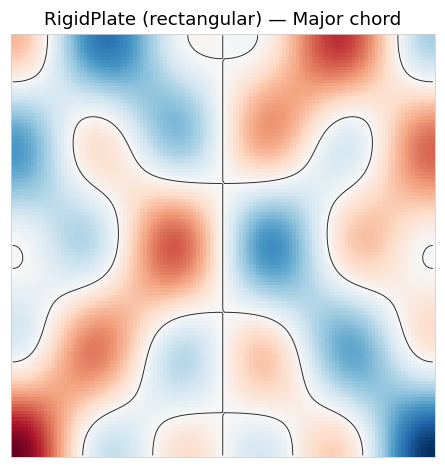

In [2]:
from biotuner.harmonic_geometry.media import RigidPlate, Rectangular

plate = RigidPlate(domain=Rectangular(Lx=1.0, Ly=1.0), resolution=128)
g     = plate.respond(CHORDS["Major"])
print("output geom_type:", g.geom_type)
print("output kind:     ", (g.metadata or {}).get("kind"))
print("output shape:    ", np.asarray(g.coordinates).shape)

fig, ax = plotting.plot_geometry(g)
ax.set_title("RigidPlate (rectangular) — Major chord");


## Domains — change the boundary, keep the chord

`Rectangular`, `Circular`, `PolygonDomain`, `Box3D`, and `Sphere` swap in
without touching the medium's other parameters.

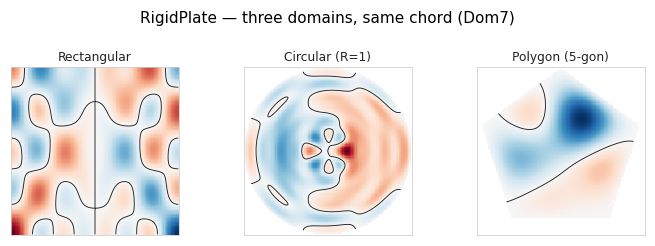

In [3]:
from biotuner.harmonic_geometry.media import Circular, PolygonDomain

domains = [
    ("Rectangular",         Rectangular(Lx=1.0, Ly=1.0)),
    ("Circular (R=1)",      Circular(R=1.0)),
    ("Polygon (5-gon)",     PolygonDomain(n_sides=5, radius=1.0)),
]
geoms = [RigidPlate(domain=d, resolution=128)(CHORDS["Dom7"])
         for _, d in domains]
plotting.gallery(geoms, titles=[name for name, _ in domains], n_cols=3,
                 suptitle="RigidPlate — three domains, same chord (Dom7)");


## Pipelines — chain media

`Pipeline(A, B, C)(chord)` is equivalent to `C(B(A(chord)))`, with the
correct forcing type negotiated at each stage. Below we feed a plate
field into the `Granular` transport medium (sand on a vibrating plate)
and into the `Tracer` flow medium (light particles advected by ∇²
streamlines of the field).

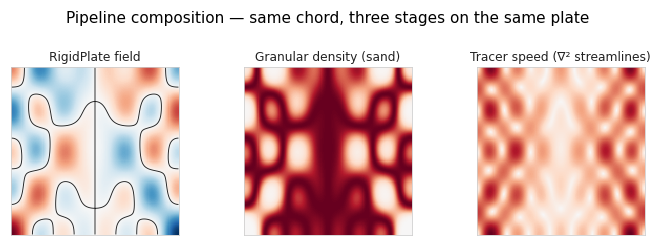

In [4]:
from biotuner.harmonic_geometry.media import Pipeline, Granular, Tracer

plate    = RigidPlate(domain=Rectangular(), resolution=160)
sand     = Pipeline(plate, Granular(n_particles=3000, output_mode="density"))
flow     = Pipeline(plate, Tracer(output_mode="speed"))

geoms = [plate(CHORDS["Dom7"]),
         sand (CHORDS["Dom7"]),
         flow (CHORDS["Dom7"])]
plotting.gallery(
    geoms,
    titles=["RigidPlate field", "Granular density (sand)",
            "Tracer speed (∇² streamlines)"],
    n_cols=3,
    suptitle="Pipeline composition — same chord, three stages on the same plate",
);


## `default_source` — transport / morphogenetic media auto-wrap

`Granular`, `Tracer`, `Streaming`, `Crystallization`, and
`ReactionDiffusion` declare a `default_source()` so they accept a
:class:`HarmonicInput` directly: the medium silently wraps the chord
through its default upstream medium. The `Granular` default is a square
:class:`RigidPlate`, so the two snippets below are equivalent.

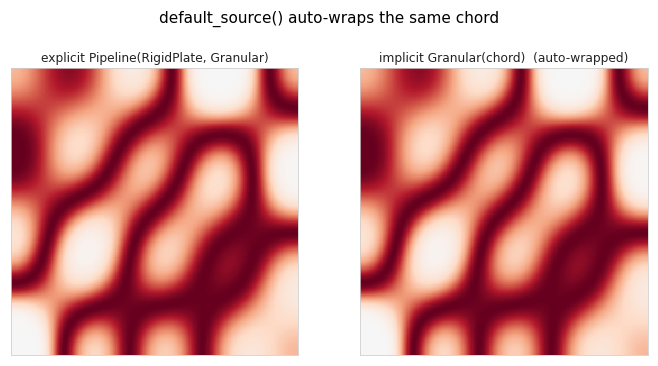

In [5]:
# Explicit two-stage pipeline:
explicit = Pipeline(RigidPlate(), Granular(n_particles=3000))(CHORDS["Sus4"])

# Implicit: pass a chord straight to Granular and let it auto-wrap.
implicit = Granular(n_particles=3000)(CHORDS["Sus4"])

plotting.gallery([explicit, implicit],
                 titles=["explicit Pipeline(RigidPlate, Granular)",
                         "implicit Granular(chord)  (auto-wrapped)"],
                 n_cols=2,
                 suptitle="default_source() auto-wraps the same chord");
